<a href="https://colab.research.google.com/github/JaskarJeyabalan/Cab-Fare-Prediction-/blob/main/Cab_Fare_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Project Statement -**
You are a cab rental start-up company. you have successfully run the plot project and now want to launch your cab sercice across the country. You have collected the historical data from your plot project and now have a requirement to apply analytics for fare prediction. You need to design a system that predicts the fare amount for cab  ride in the city.

In [ ]:
# importing required Libraires
import os # for input output operations
import pandas as pd # for dataframe operations
import numpy as np
import matplotlib.pyplot as plt # for data visualizations
import seaborn as sns # for data visualizations interactive images
from collections import Counter # for counting the values
from sklearn.model_selection import train_test_split # for splitting the data into train and test
from sklearn.linear_model import LinearRegression # for linear regression model
from sklearn.tree import DecisionTreeRegressor # for decision tree regression model
from sklearn.ensemble import RandomForestRegressor # for random forest regression model
from sklearn.ensemble import GradientBoostingRegressor # for gradient boosting regression model
from sklearn.metrics import mean_squared_error # for calculating the mean squared error
from sklearn.metrics import r2_score # for calculating the r2 score
from pprint import pprint # for printing the parameters
from sklearn.model_selection import RandomizedSearchCV # for random search
from sklearn.model_selection import GridSearchCV # for grid search

%matplotlib inline

In [ ]:
# Setting the working directory

os.chdir("/content")
print(os.getcwd())

/content


In [ ]:
# Loading the data
train = pd.read_csv("train_cab.csv")
test = pd.read_csv("test_cab.csv")

In [ ]:
train

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1.0
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1.0
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2.0
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1.0
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1.0
...,...,...,...,...,...,...,...
16062,6.5,2014-12-12 07:41:00 UTC,-74.008820,40.718757,-73.998865,40.719987,1.0
16063,16.1,2009-07-13 07:58:00 UTC,-73.981310,40.781695,-74.014392,40.715527,2.0
16064,8.5,2009-11-11 11:19:07 UTC,-73.972507,40.753417,-73.979577,40.765495,1.0
16065,8.1,2010-05-11 23:53:00 UTC,-73.957027,40.765945,-73.981983,40.779560,1.0


In [ ]:
test

,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1
...,...,...,...,...,...,...
9909,2015-05-10 12:37:51 UTC,-73.968124,40.796997,-73.955643,40.780388,6
9910,2015-01-12 17:05:51 UTC,-73.945511,40.803600,-73.960213,40.776371,6
9911,2015-04-19 20:44:15 UTC,-73.991600,40.726608,-73.789742,40.647011,6
9912,2015-01-31 01:05:19 UTC,-73.985573,40.735432,-73.939178,40.801731,6


##**Understanding the dataset**

In [ ]:
train.head() # checking first five rows of the training dataset

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1.0
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1.0
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2.0
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1.0
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1.0


In [ ]:
test.head() # checking first five rows of the testing dataset

,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1


In [ ]:
print("Shape of the training dataset: ", train.shape) # checking the number of rows & columns in train dataset
print("Shape of the testing dataset: ", test.shape) # checking the number of rows & columns in test dataset

Shape of the training dataset:  (16067, 7)
Shape of the testing dataset:  (9914, 6)


In [ ]:
train.dtypes # checking the datatypes in train dataset

,0
fare_amount,object
pickup_datetime,object
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,float64


In [ ]:
test.dtypes # checking the datatypes in test dataset

,0
pickup_datetime,object
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64


In [ ]:
train.describe() # checking the statistical summary of the train dataset

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,16067.000000,16067.000000,16067.000000,16067.000000,16012.000000
mean,-72.462787,39.914725,-72.462328,39.897906,2.625070
std,10.578384,6.826587,10.575062,6.187087,60.844122
min,-74.438233,-74.006893,-74.429332,-74.006377,0.000000
25%,-73.992156,40.734927,-73.991182,40.734651,1.000000
50%,-73.981698,40.752603,-73.980172,40.753567,1.000000
75%,-73.966838,40.767381,-73.963642,40.768014,2.000000
max,40.766125,401.083332,40.802437,41.366138,5345.000000


In [ ]:
test.describe() # checking the statistical summary of the test dataset

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974722,40.751041,-73.973657,40.751743,1.671273
std,0.042774,0.033541,0.039072,0.035435,1.278747
min,-74.252193,40.573143,-74.263242,40.568973,1.000000
25%,-73.992501,40.736125,-73.991247,40.735254,1.000000
50%,-73.982326,40.753051,-73.980015,40.754065,1.000000
75%,-73.968013,40.767113,-73.964059,40.768757,2.000000
max,-72.986532,41.709555,-72.990963,41.696683,6.000000


##**Data Pre-processing**

**Data Exploring and Missing Value Analysis**

In [ ]:
train.isnull().sum() # checking the missing values in train dataset

,0
fare_amount,24
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,55


In [ ]:
test.isnull().sum() # checking the missing values in test dataset

,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


In [ ]:
# Convert fare_amount from object to numeric
train['fare_amount'] = pd.to_numeric(train['fare_amount'], errors='coerce') # Using errors='coerce'. It will replace all non-null values

In [ ]:
train.dtypes

,0
fare_amount,float64
pickup_datetime,object
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,float64


In [ ]:
train.shape

(16067, 7)

In [ ]:
train.dropna(subset=['pickup_datetime']) # Droping NA values in datetime column

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1.0
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1.0
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2.0
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1.0
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1.0
...,...,...,...,...,...,...,...
16062,6.5,2014-12-12 07:41:00 UTC,-74.008820,40.718757,-73.998865,40.719987,1.0
16063,16.1,2009-07-13 07:58:00 UTC,-73.981310,40.781695,-74.014392,40.715527,2.0
16064,8.5,2009-11-11 11:19:07 UTC,-73.972507,40.753417,-73.979577,40.765495,1.0
16065,8.1,2010-05-11 23:53:00 UTC,-73.957027,40.765945,-73.981983,40.779560,1.0


In [ ]:
# Converting pickup_datetime from object to datetime
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'], format='%Y-%m-%d %H:%M:%S UTC', errors='coerce')

In [ ]:
# We will be seperating the pickup_datetime function into year, month, day ect...
train['year'] = train['pickup_datetime'].dt.year
train['month'] = train['pickup_datetime'].dt.month
train['date'] = train['pickup_datetime'].dt.day
train['day'] = train['pickup_datetime'].dt.dayofweek
train['hour'] = train['pickup_datetime'].dt.hour
train['minute'] = train['pickup_datetime'].dt.minute

In [ ]:
train.dtypes # Re-checking train data-types after conversion

,0
fare_amount,float64
pickup_datetime,datetime64[ns]
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,float64
year,float64
month,float64
date,float64


In [ ]:
test.dtypes

,0
pickup_datetime,object
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64


In [ ]:
test.shape

(9914, 6)

In [ ]:
test.dropna(subset=['pickup_datetime']) # Droping NA values in datetime column

,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1
...,...,...,...,...,...,...
9909,2015-05-10 12:37:51 UTC,-73.968124,40.796997,-73.955643,40.780388,6
9910,2015-01-12 17:05:51 UTC,-73.945511,40.803600,-73.960213,40.776371,6
9911,2015-04-19 20:44:15 UTC,-73.991600,40.726608,-73.789742,40.647011,6
9912,2015-01-31 01:05:19 UTC,-73.985573,40.735432,-73.939178,40.801731,6


In [ ]:
# Converting pickup_datetime from object to datetime
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'], format='%Y-%m-%d %H:%M:%S UTC')

In [ ]:
# We will be seperating the pickup_datetime function into year, month, day ect...
test['year'] = test['pickup_datetime'].dt.year
test['month'] = test['pickup_datetime'].dt.month
test['date'] = test['pickup_datetime'].dt.day
test['day'] = test['pickup_datetime'].dt.dayofweek
test['hour'] = test['pickup_datetime'].dt.hour
test['minute'] = test['pickup_datetime'].dt.minute

In [ ]:
test.dtypes # Re-checking train data-types after conversion

,0
pickup_datetime,datetime64[ns]
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64
year,int32
month,int32
date,int32
day,int32


Missing Value Analysis

In [ ]:
# Removing datetime missing value rows
train = train.drop(train[train['pickup_datetime'].isnull()].index, axis = 0)
print("Total Train Rows & Columns:", train.shape)
print("Pickup Datetime Null Value:", train['pickup_datetime'].isnull().sum())

Total Train Rows & Columns: (16066, 13)
Pickup Datetime Null Value: 0


In [ ]:
train["passenger_count"].describe()

,passenger_count
count,16011.000000
mean,2.625171
std,60.846021
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5345.000000


We can see maximum number of passenger count is 5345 which is actually not possible. So reducing the passenger count to 6(even if we consider the SUV)

In [ ]:
train = train.drop(train[train['passenger_count'] > 6].index, axis=0)

In [ ]:
# Also removing the values with passenger count of 0.
train = train.drop(train[train['passenger_count'] == 0].index, axis=0)

In [ ]:
train['passenger_count'].describe()

,passenger_count
count,15934.000000
mean,1.649581
std,1.265943
min,0.120000
25%,1.000000
50%,1.000000
75%,2.000000
max,6.000000


In [ ]:
train['passenger_count'].sort_values(ascending=True)

,passenger_count
8862,0.12
7617,1.00
7589,1.00
7587,1.00
12882,1.00
...,...
8076,NaN
8139,NaN
8259,NaN
8306,NaN


In [ ]:
# Removing passenger_count missing value rows
train = train.drop(train[train['passenger_count'].isnull()].index, axis = 0)
print("Total Train Rows & Columns:", train.shape)
print("Passenger Count Null Value:", train['passenger_count'].isnull().sum())

Total Train Rows & Columns: (15934, 13)
Passenger Count Null Value: 0


There is one passenger count value of 0.12 which is not possible. Hence we will remove fractional passenger value.

In [ ]:
train = train.drop(train[train['passenger_count'] == 0.12].index, axis=0)
print("Total Train Rows & Columns:", train.shape)

Total Train Rows & Columns: (15933, 13)


In [ ]:
# Find descending order of fare to get to know whether the outliers are present or not
train['fare_amount'].sort_values(ascending=False)

,fare_amount
1015,54343.0
1072,4343.0
607,453.0
980,434.0
1335,180.0
...,...
1712,NaN
2412,NaN
2458,NaN
8178,NaN


In [ ]:
# Count the number of values in the fare_amount is less than zero.
Counter(train['fare_amount']<0)

Counter({False: 15930, True: 3})

In [ ]:
# Remove the rows negative value in the fare_amount variable column.
train = train.drop(train[train['fare_amount']<1].index, axis=0)
print("Total Train Rows & Columns:", train.shape)

Total Train Rows & Columns: (15928, 13)


In [ ]:
# Check the minimum value in the fare_amount variable and verify if there is any negative value.
train['fare_amount'].min()

1.14

In [ ]:
# There is a huge difference in 1st, 2nd, 3rd position in descending order of fare_amount
train = train.drop(train[train['fare_amount']>454].index, axis=0)
print("Total Train Rows & Columns:", train.shape)

Total Train Rows & Columns: (15926, 13)


In [ ]:
# Removing the missing value rows in the fare_amount
train = train.drop(train[train['fare_amount'].isnull()].index, axis = 0)
print("Total Train Rows & Columns:", train.shape)
print("Fare Amount Null Value:", train['fare_amount'].isnull().sum())

Total Train Rows & Columns: (15902, 13)
Fare Amount Null Value: 0


In [ ]:
train['fare_amount'].sort_values(ascending=False) # Re-checking outliers

,fare_amount
607,453.00
980,434.00
1335,180.00
1483,165.00
6630,128.83
...,...
4367,2.50
6297,2.50
3558,2.50
6226,2.50


In [ ]:
train['fare_amount'].describe()

,fare_amount
count,15902.000000
mean,11.376356
std,10.814908
min,1.140000
25%,6.000000
50%,8.500000
75%,12.500000
max,453.000000


In [ ]:
# Latitude can be from -90 to 90
# Longitude can be from -180 to 180

# Checking the pickup_latitude values less than -90
train[train['pickup_latitude'] < -90]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute


In [ ]:
# Checking the latitude values greater than 90
train[train['pickup_latitude'] > 90]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute
5686,3.3,2011-07-30 11:15:00,-73.947235,401.083332,-73.951392,40.778927,1.0,2011.0,7.0,30.0,5.0,11.0,15.0


In [ ]:
# Hence droping one value which is less than -90 and greater than 90
train = train.drop(train[train['pickup_latitude'] < -90].index, axis=0)
train = train.drop(train[train['pickup_latitude'] > 90].index, axis=0)

In [ ]:
print("Total Train Rows & Columns:", train.shape)

Total Train Rows & Columns: (15901, 13)


In [ ]:
# Checking the pickup_longitude values less than -180
train[train['pickup_longitude'] < -180]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute


In [ ]:
# Checking the pickup_longitude values greater than 180
train[train['pickup_latitude'] > 180]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute


In [ ]:
# Checking for dropoff_latitude values less than -90
train[train['dropoff_latitude'] < -90]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute


In [ ]:
# Checking for dropoff_latitude values greater than 90
train[train['dropoff_latitude'] > 90]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute


In [ ]:
#  Checking for dropoff_longitude values less than -180
train[train['dropoff_longitude'] < -180]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute


In [ ]:
# Checking for dropoff_longitude values greater than 180
train[train['dropoff_longitude'] > 180]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute


In [ ]:
print("Total Train Rows & Columns:", train.shape)

Total Train Rows & Columns: (15901, 13)


In [ ]:
print("Total Train Null Value:\n", train.isnull().sum())

Total Train Null Value:
 fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
year                 0
month                0
date                 0
day                  0
hour                 0
minute               0
dtype: int64


In [ ]:
print("Total Test Rows & Columns:", test.shape)

Total Test Rows & Columns: (9914, 12)


In [ ]:
print("Total Test Null Value:\n", test.isnull().sum())

Total Test Null Value:
 pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
year                 0
month                0
date                 0
day                  0
hour                 0
minute               0
dtype: int64


Data pre-processing and cleaning done.

Calculate the distance based on given ordinates

In [ ]:
# We have been given pickup Latitudes, Longitudes and dropoff Latitudes, Longitudes
# So  we need to calculate the distance using the haversine formula and we will create a new variable called distance

from math import radians, cos, sin, asin, sqrt

def haversine(a):
  lon1 = a[0] # pickup_longitude
  lat1 = a[1] # pickup_latitude
  lon2 = a[2] # dropoff_longitude
  lat2 = a[3] # dropoff_latitude

  "Calculating the great circle distance between two points on the earth (specified in decimal degrees)"

  # Convert decimal degrees to radians
  lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

  # Heversine formula
  dlon = lon2 - lon1
  dlat = lat2 - lat1
  a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
  c = 2 * asin(sqrt(a))

  # Radius of earth in kilometers is 6371
  km = 6371 * c
  return km


In [ ]:

train['distance'] = train[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].apply(haversine, axis=1)

/tmp/ipython-input-2743867191.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lon1 = a[0] # pickup_longitude
/tmp/ipython-input-2743867191.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lat1 = a[1] # pickup_latitude
/tmp/ipython-input-2743867191.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lon2 = a[2] # dropoff_longitude
/tmp/ipython-input-2743867191.py:10: FutureWarning: Series.__getitem__ treating keys as positions

In [ ]:
test['distance'] = test[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].apply(haversine, axis=1)

/tmp/ipython-input-2743867191.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lon1 = a[0] # pickup_longitude
/tmp/ipython-input-2743867191.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lat1 = a[1] # pickup_latitude
/tmp/ipython-input-2743867191.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lon2 = a[2] # dropoff_longitude
/tmp/ipython-input-2743867191.py:10: FutureWarning: Series.__getitem__ treating keys as positions

In [ ]:
train.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute,distance
0,4.5,2009-06-15 17:26:21,-73.844311,40.721319,-73.841610,40.712278,1.0,2009.0,6.0,15.0,0.0,17.0,26.0,1.030764
1,16.9,2010-01-05 16:52:16,-74.016048,40.711303,-73.979268,40.782004,1.0,2010.0,1.0,5.0,1.0,16.0,52.0,8.450134
2,5.7,2011-08-18 00:35:00,-73.982738,40.761270,-73.991242,40.750562,2.0,2011.0,8.0,18.0,3.0,0.0,35.0,1.389525
3,7.7,2012-04-21 04:30:42,-73.987130,40.733143,-73.991567,40.758092,1.0,2012.0,4.0,21.0,5.0,4.0,30.0,2.799270
4,5.3,2010-03-09 07:51:00,-73.968095,40.768008,-73.956655,40.783762,1.0,2010.0,3.0,9.0,1.0,7.0,51.0,1.999157


In [ ]:
test.head()

,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,date,day,hour,minute,distance
0,2015-01-27 13:08:24,-73.973320,40.763805,-73.981430,40.743835,1,2015,1,27,1,13,8,2.323259
1,2015-01-27 13:08:24,-73.986862,40.719383,-73.998886,40.739201,1,2015,1,27,1,13,8,2.425353
2,2011-10-08 11:53:44,-73.982524,40.751260,-73.979654,40.746139,1,2011,10,8,5,11,53,0.618628
3,2012-12-01 21:12:12,-73.981160,40.767807,-73.990448,40.751635,1,2012,12,1,5,21,12,1.961033
4,2012-12-01 21:12:12,-73.966046,40.789775,-73.988565,40.744427,1,2012,12,1,5,21,12,5.387301


In [ ]:
train.nunique()

,0
fare_amount,459
pickup_datetime,15856
pickup_longitude,13672
pickup_latitude,14110
dropoff_longitude,13763
dropoff_latitude,14136
passenger_count,7
year,7
month,12
date,31


In [ ]:
test.nunique()

,0
pickup_datetime,1753
pickup_longitude,9124
pickup_latitude,9246
dropoff_longitude,9141
dropoff_latitude,9360
passenger_count,6
year,7
month,12
date,31
day,7


In [ ]:
# Finding decending order of distance to get to know whether the outliers are present or not
train['distance'].sort_values(ascending=False)

,distance
9147,8667.542104
8647,8667.497512
2397,8667.454421
472,8667.304968
11653,8666.701504
...,...
4653,0.000000
9270,0.000000
9266,0.000000
660,0.000000


The top 23 distance values in the distance variables are very high. It means more than 8000 kms distance they have travelled. Also just after 23rd value from the top. The distance goes down to 127. Which means these values are showing some outliers. We need to remove these values.

In [ ]:
# We will remove the rows whose distance values is very high which is more than 129kms
train = train.drop(train[train['distance'] > 130].index, axis=0)
train.shape

(15878, 14)

In [ ]:
Counter(train['distance'] == 0)

Counter({False: 15424, True: 454})

In [ ]:
Counter(test['distance'] == 0)

Counter({False: 9829, True: 85})

In [ ]:
# We will remove the rows whose distance values is zero
train = train.drop(train[train['distance'] == 0].index, axis=0)
train.shape

(15424, 14)

In [ ]:
test = test.drop(test[test['distance'] == 0].index, axis=0)
test.shape

(9829, 13)

We have splitted the pickup_datetime variable into different variables like year, month, day etc so now we don't need to have that pickup_datetime variable now. Hence we can drop that. Also we have created distance using pickup and dropoff lonitudes and latitudes so we will also drop pickup and dropoff lonitudes and latitudes variables.

In [ ]:
drop_train = ['pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'minute']
train = train.drop(drop_train, axis=1)

In [ ]:
train.head()

,fare_amount,passenger_count,year,month,date,day,hour,distance
0,4.5,1.0,2009.0,6.0,15.0,0.0,17.0,1.030764
1,16.9,1.0,2010.0,1.0,5.0,1.0,16.0,8.450134
2,5.7,2.0,2011.0,8.0,18.0,3.0,0.0,1.389525
3,7.7,1.0,2012.0,4.0,21.0,5.0,4.0,2.799270
4,5.3,1.0,2010.0,3.0,9.0,1.0,7.0,1.999157


In [ ]:
train.dtypes

,0
fare_amount,float64
passenger_count,float64
year,float64
month,float64
date,float64
day,float64
hour,float64
distance,float64


In [ ]:
# Converting variables of float datatype into int datatype
train['passenger_count'] = train['passenger_count'].astype('int64')
train['year'] = train['year'].astype('int64')
train['month'] = train['month'].astype('int64')
train['date'] = train['date'].astype('int64')
train['day'] = train['day'].astype('int64')
train['hour'] = train['hour'].astype('int64')

In [ ]:
train.head()

,fare_amount,passenger_count,year,month,date,day,hour,distance
0,4.5,1,2009,6,15,0,17,1.030764
1,16.9,1,2010,1,5,1,16,8.450134
2,5.7,2,2011,8,18,3,0,1.389525
3,7.7,1,2012,4,21,5,4,2.799270
4,5.3,1,2010,3,9,1,7,1.999157


In [ ]:
train.dtypes

,0
fare_amount,float64
passenger_count,int64
year,int64
month,int64
date,int64
day,int64
hour,int64
distance,float64


In [ ]:
drop_test = ['pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'minute']
test = test.drop(drop_test, axis=1)

In [ ]:
test.head()

,passenger_count,year,month,date,day,hour,distance
0,1,2015,1,27,1,13,2.323259
1,1,2015,1,27,1,13,2.425353
2,1,2011,10,8,5,11,0.618628
3,1,2012,12,1,5,21,1.961033
4,1,2012,12,1,5,21,5.387301


In [ ]:
test.dtypes

,0
passenger_count,int64
year,int32
month,int32
date,int32
day,int32
hour,int32
distance,float64


### **Data Visualization**

**Visualization of following:**

1. Number of Passengers effects the fare
2. Pickup date and time effects the fare
3. Day of the week does effects the fare
4. Distance effects the fare

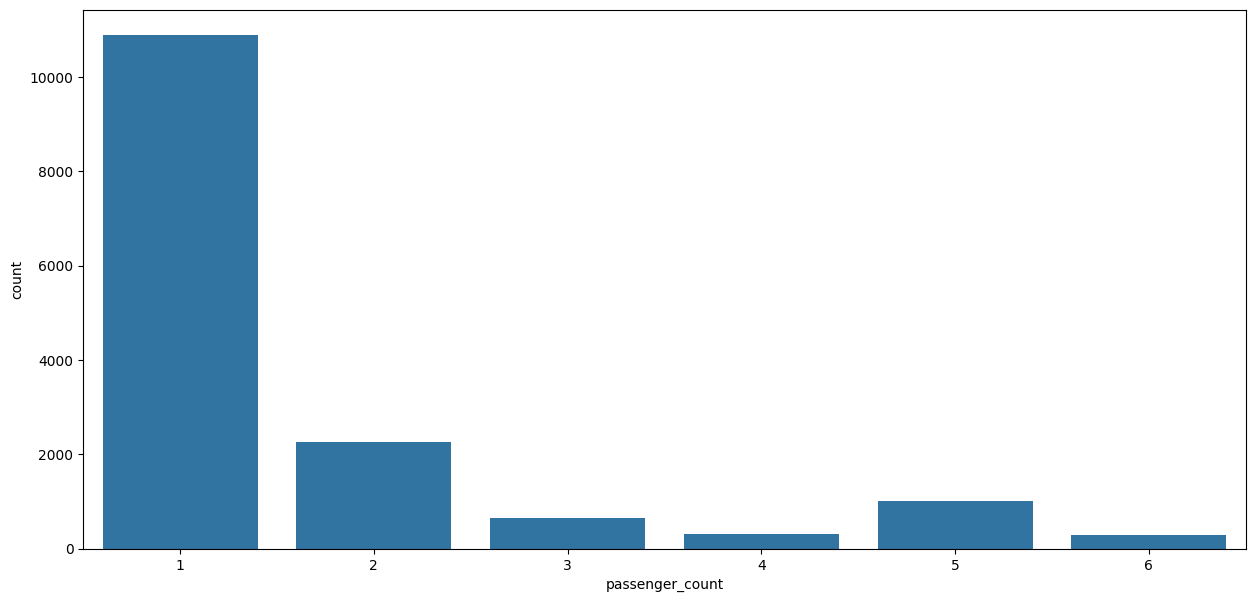

In [ ]:
# Count plot on passenger count

plt.figure(figsize=(15,7))
sns.countplot(x='passenger_count', data=train)
plt.show()

Single and double travelling passengers are the most frequent rides taken

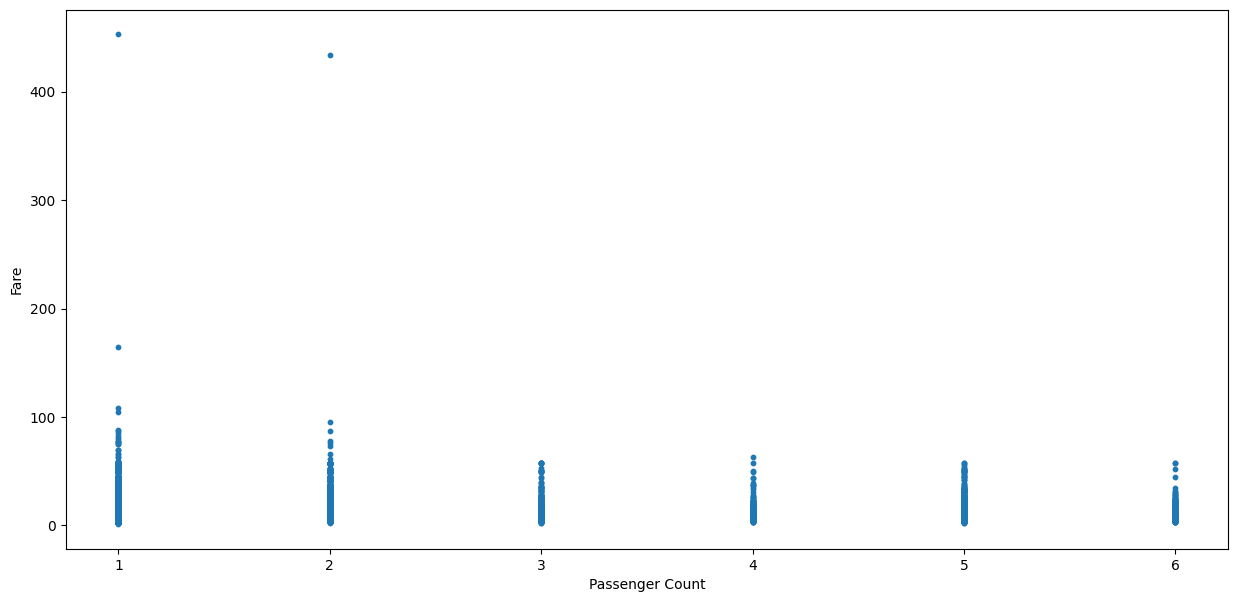

In [ ]:
# Relationship between number of passengers and fare

plt.figure(figsize=(15,7))
plt.scatter(x=train['passenger_count'], y=train['fare_amount'], s=10)
plt.xlabel('Passenger Count')
plt.ylabel('Fare')
plt.show()

Observation from the above plot we can easily conculde that:

1. Single travelling passengers are most frequent travellers.
2. All the sametime we can also conclude that highest **Fare Amount** are coming from single & double travelling passenger.

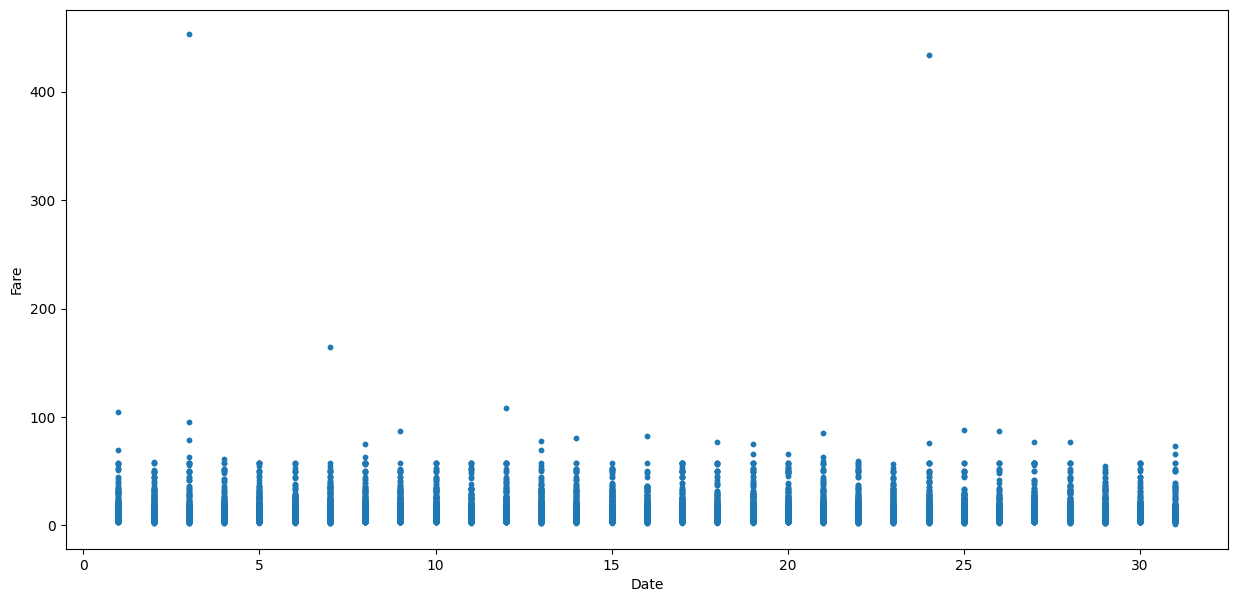

In [ ]:
# Relationship between date and fare

plt.figure(figsize=(15,7))
plt.scatter(x=train['date'], y=train['fare_amount'], s=10)
plt.xlabel('Date')
plt.ylabel('Fare')
plt.show()

Fare is almost equal on all days of the month

<function matplotlib.pyplot.show(close=None, block=None)>

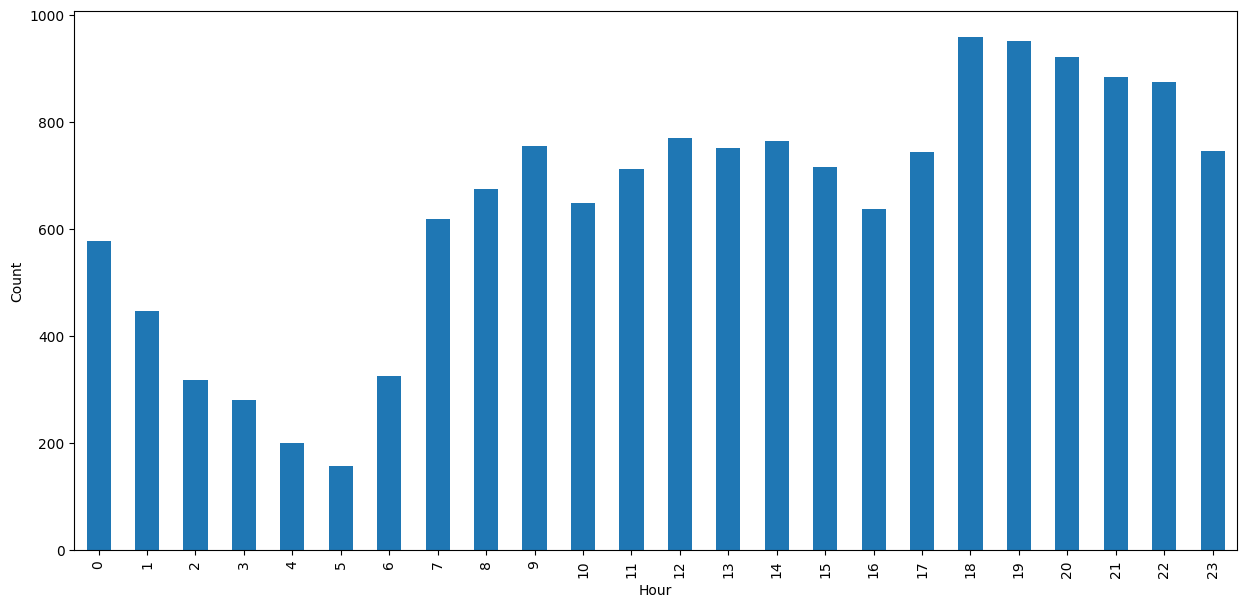

In [ ]:
# Relationship between the hour of the day and fare

plt.figure(figsize=(15,7))
train.groupby(train['hour'])['hour'].count().plot(kind="bar")
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show

Lowest number of cabs were at around 5 AM and highest number of cabs were between 6 PM to 7 PM.

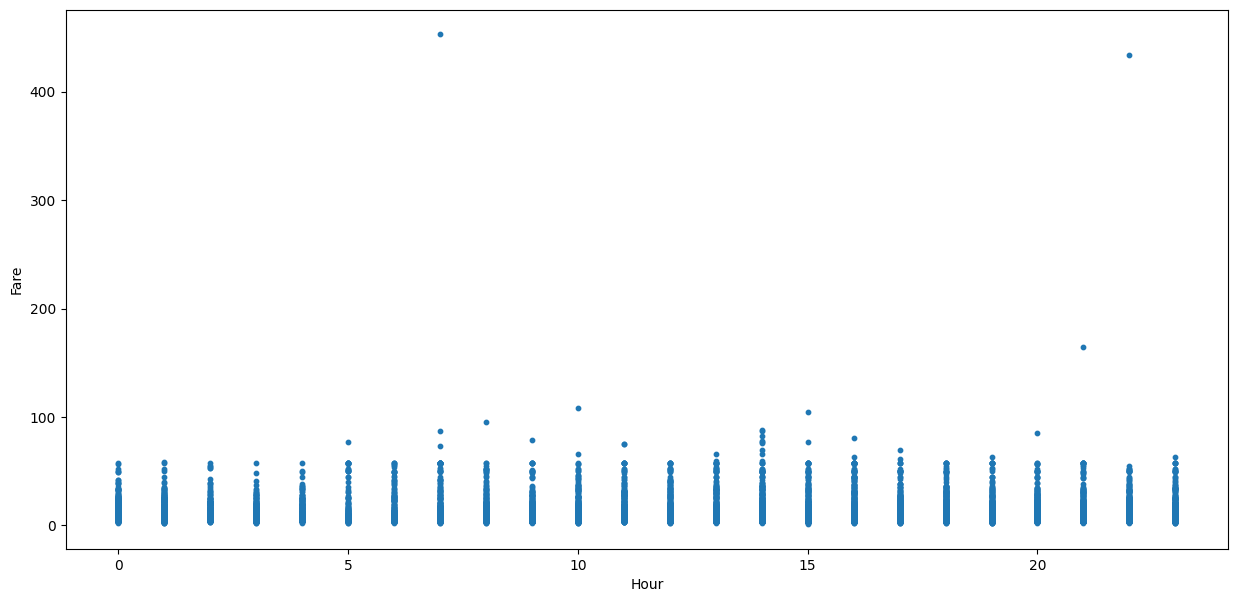

In [ ]:
# Relationship between time and fare

plt.figure(figsize=(15,7))
plt.scatter(x=train['hour'], y=train['fare_amount'], s=10)
plt.xlabel('Hour')
plt.ylabel('Fare')
plt.show()

Cabs taken at 7 AM and 11 PM are the costliest. Hence we can assume that cabs taken early in the morning and late at night is costliest.

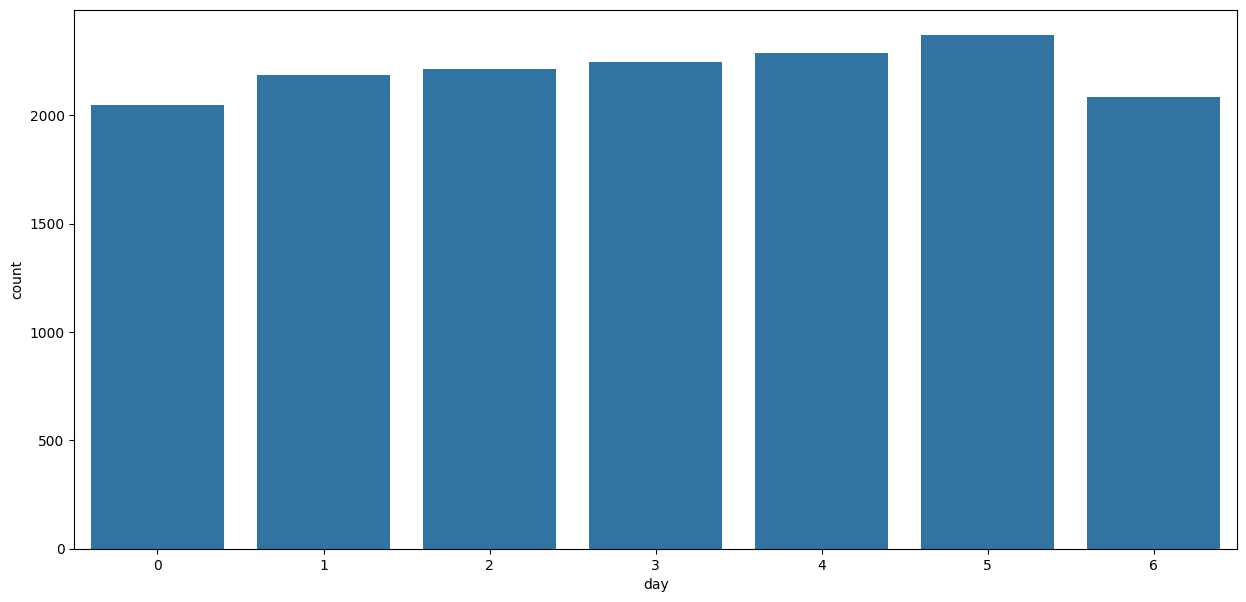

In [ ]:
# Impact of day on the number of cab rides

plt.figure(figsize=(15,7))
sns.countplot(x='day', data=train)
plt.show()

Not much relation between the day of the week and the count of the number of cars.

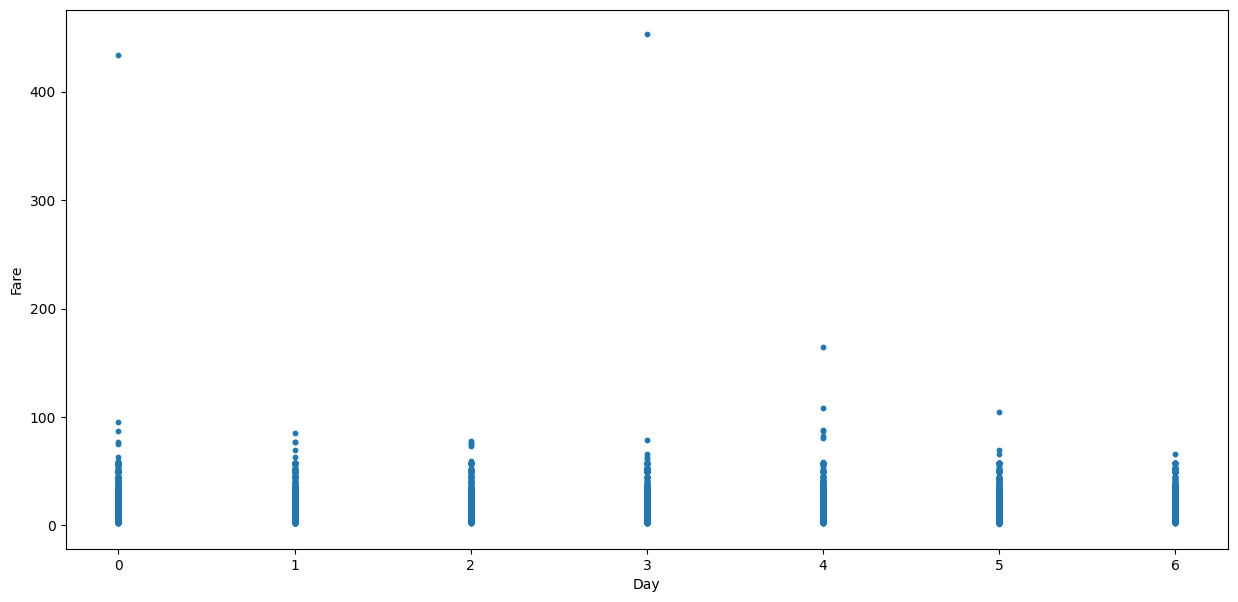

In [ ]:
# Relationship between day and fare

plt.figure(figsize=(15,7))
plt.scatter(x=train['day'], y=train['fare_amount'], s=10)
plt.xlabel('Day')
plt.ylabel('Fare')
plt.show()

The highest fare seem to be on a Sunday, Monday and Thursday, and the low on Wednesday and Saturday. May be due to low demand of the cabs on Saturdays the cab fare is low and high demand of cabs on Sunday and Monday show the high fare prices.

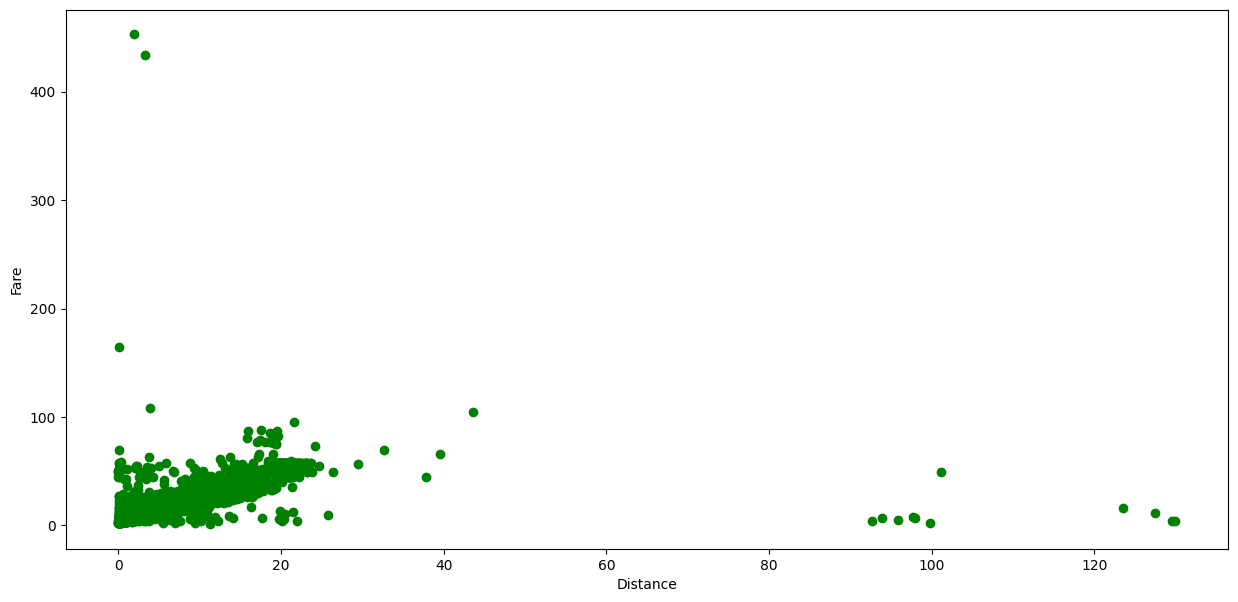

In [ ]:
# Relationship between distance and fare

plt.figure(figsize=(15,7))
plt.scatter(x=train['distance'], y=train['fare_amount'], c="g")
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.show()

Distance is showing directly proportional to fare charged as the increasing the fare charge is also increasing.

###**Feature Scaling**

fare_amount


/tmp/ipython-input-1420091638.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[i], bins='auto', color='green')


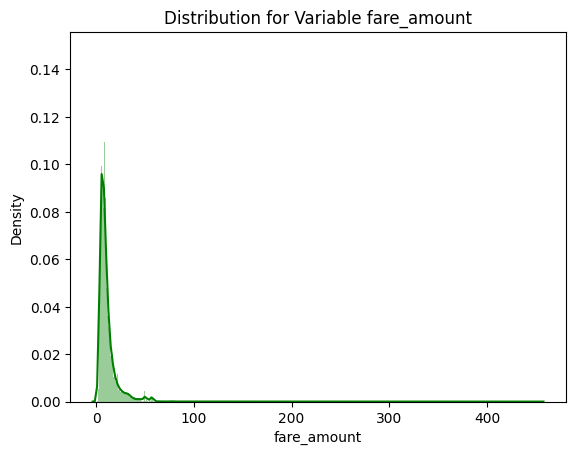

distance


/tmp/ipython-input-1420091638.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[i], bins='auto', color='green')


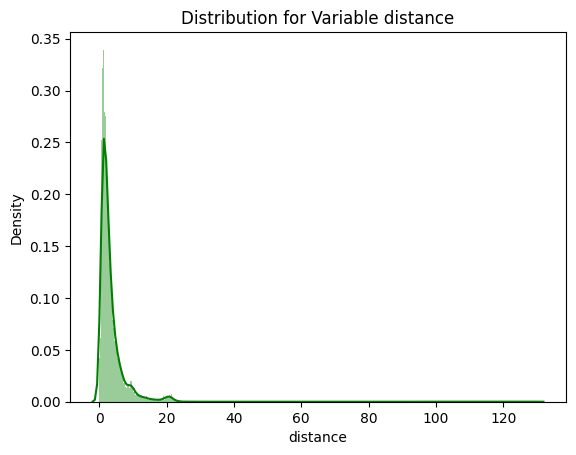

In [ ]:
# Normality check of training data is uniformly distributed or not-

for i in ['fare_amount', 'distance']:
  print(i)
  sns.distplot(train[i], bins='auto', color='green')
  plt.title('Distribution for Variable '+i)
  plt.ylabel('Density')
  plt.show()

In [ ]:
# Since skewness of fare_amount is high, apply log transform to reduce the skewness-
train['fare_amount'] = np.log1p(train['fare_amount'])

# Since skewness of distance is high, apply log transform to reduce the skewness-
train['distance'] = np.log1p(train['distance'])

fare_amount


/tmp/ipython-input-3985273932.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[i], bins='auto', color='green')


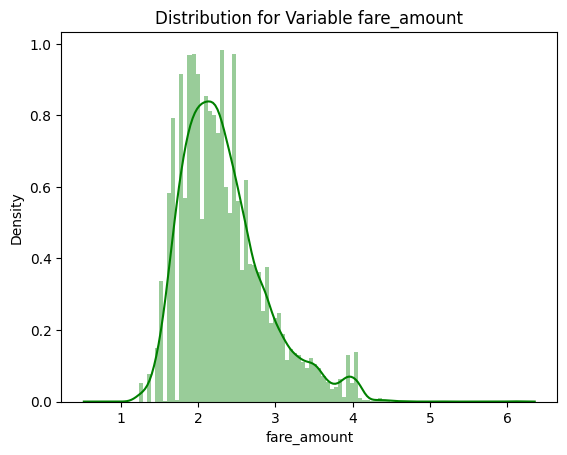

distance


/tmp/ipython-input-3985273932.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[i], bins='auto', color='green')


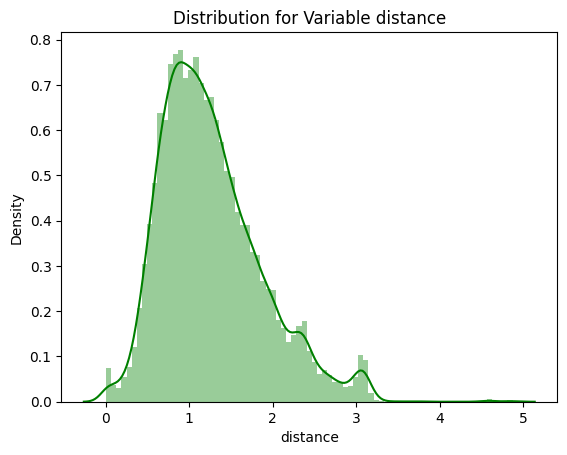

In [ ]:
# Normality re-check to check data is uniformly distributed or not after log transformation

for i in ['fare_amount', 'distance']:
  print(i)
  sns.distplot(train[i], bins='auto', color='green')
  plt.title('Distribution for Variable '+i)
  plt.ylabel('Density')
  plt.show()

distance


/tmp/ipython-input-567494252.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test[i], bins='auto', color='green')


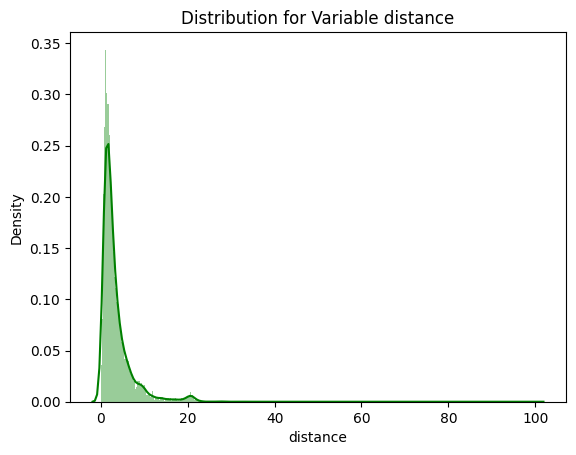

In [ ]:
# Normality check of test data is uniformly distributed or not-

for i in ['distance']:
  print(i)
  sns.distplot(test[i], bins='auto', color='green')
  plt.title('Distribution for Variable '+i)
  plt.ylabel('Density')
  plt.show()

In [ ]:
# Since skewness of distance is high, apply log transform to reduce the skewness-
test['distance'] = np.log1p(test['distance'])

distance


/tmp/ipython-input-4125551812.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test[i], bins='auto', color='green')


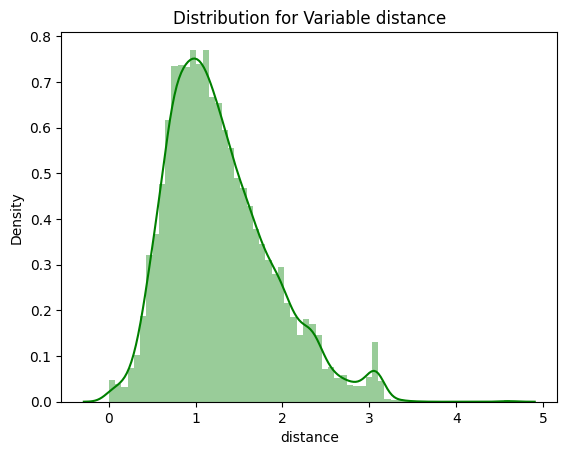

In [ ]:
# Normality re-check to check data is uniformly distributed or not after log transformation

for i in ['distance']:
  print(i)
  sns.distplot(test[i], bins='auto', color='green')
  plt.title('Distribution for Variable '+i)
  plt.ylabel('Density')
  plt.show()

As we can see a bell shaped distribution. Hence our continous variables are now normaly distributed. We will use any Feature Scalling technique, i.e, Normalization or Standarization for our test data.

###**Data Modeling - Applying ML Algorithms**

In [ ]:
# train test split for further modeling

X_train, X_test, y_train, y_test = train_test_split(train.iloc[:, train.columns != 'fare_amount'],
                                                    train.iloc[:, 0], test_size = 0.20, random_state = 1)

In [ ]:
X_train

,passenger_count,year,month,date,day,hour,distance
7690,2,2012,5,16,2,6,1.691253
13018,1,2014,7,11,4,10,0.828231
12950,3,2009,6,27,5,17,0.980620
14009,1,2009,6,12,4,15,0.534072
2816,5,2013,5,18,5,20,1.141300
...,...,...,...,...,...,...,...
994,1,2009,3,24,1,11,1.465260
5454,1,2014,1,11,5,18,0.666875
12682,6,2014,1,7,1,9,1.437090
259,1,2013,5,2,3,3,0.803939


In [ ]:
y_train

,fare_amount
7690,2.370244
13018,2.014903
12950,2.014903
14009,1.629241
2816,2.890372
...,...
994,2.687847
5454,1.704748
12682,2.917771
259,1.945910


In [ ]:
print('X_train', X_train.shape)
print('X_test', X_test.shape)

X_train (12339, 7)
X_test (3085, 7)


In [ ]:
print('y_train', y_train.shape)
print('y_test', y_test.shape)

y_train (12339,)
y_test (3085,)


In [ ]:
type(y_train)

pandas.core.series.Series

**Linear Regression**

In [ ]:
# Fitting the model on the train data
fit_lr = LinearRegression()
fit_lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Prediction on train data
pred_train_lr = fit_lr.predict(X_train)

In [ ]:
# Prediction on test data
pred_test_lr = fit_lr.predict(X_test)

In [ ]:
# Calculate RMSE for train data
RMSE_train_lr = np.sqrt(mean_squared_error(y_train, pred_train_lr))

# Calculate RMSE for test data
RMSE_test_lr = np.sqrt(mean_squared_error(y_test, pred_test_lr))

In [ ]:
print("Root Mean Squared Error For Train data = " +str(RMSE_train_lr))
print("Root Mean Squared Error For Test data = " +str(RMSE_test_lr))

Root Mean Squared Error For Train data = 0.27531100179673135
Root Mean Squared Error For Test data = 0.2454066178697775


In [ ]:
# Calculate R^2 for train data

from sklearn.metrics import r2_score
r2_score(y_train, pred_train_lr)

0.7495502651880405

In [ ]:
# Calculate R^2 for test data
r2_score(y_test, pred_test_lr)

0.7827019104296596

**Decision Tree Model**

In [ ]:
# Fitting the model on the train data
fit_dt = DecisionTreeRegressor(max_depth = 2)
fit_dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2)

In [ ]:
# Prediction on train data
pred_train_dt = fit_dt.predict(X_train)

# Prediction on test data
pred_test_dt = fit_dt.predict(X_test)

In [ ]:
# Calculate RMSE for train data
RMSE_train_dt = np.sqrt(mean_squared_error(y_train, pred_train_dt))

# Calculate RMSE for test data
RMSE_test_dt = np.sqrt(mean_squared_error(y_test, pred_test_dt))

In [ ]:
print("Root Mean Squared Error For Train data = " +str(RMSE_train_dt))
print("Root Mean Squared Error For Test data = " +str(RMSE_test_dt))

Root Mean Squared Error For Train data = 0.2996210902077019
Root Mean Squared Error For Test data = 0.2867460617158618


In [ ]:
# Calculate R^2 for train data
r2_score(y_train, pred_train_dt)

0.7033678616157003

In [ ]:
# Claculate R^2 for test data
r2_score(y_test, pred_test_dt)

0.7033268167661033

**Random Forest Model**

In [ ]:
# Fitting the model on the train data
fit_rf = RandomForestRegressor(n_estimators=200)
fit_rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200)

In [ ]:
# Prediction on train data
pred_train_rf = fit_rf.predict(X_train)

# Prediction on test data
pred_test_rf = fit_rf.predict(X_test)

In [ ]:
# Calculate RMSE for train data
RMSE_train_rf = np.sqrt(mean_squared_error(y_train, pred_train_rf))

# Calculate RMSE for test data
RMSE_test_rf = np.sqrt(mean_squared_error(y_test, pred_test_rf))

In [ ]:
print("Root Mean Squared Error For Train data = " +str(RMSE_train_rf))
print("Root Mean Squared Error For Test data = " +str(RMSE_test_rf))

Root Mean Squared Error For Train data = 0.09593857329873928
Root Mean Squared Error For Test data = 0.23565255038421004


In [ ]:
# Calculate R^2 for train data
r2_score(y_train, pred_train_rf)

0.9695869515157414

In [ ]:
# Calculate R^2 for test data
r2_score(y_test, pred_test_rf)

0.7996323260611838

**Gradiet Boosting**

In [ ]:
# Fitting the model on the train data
fit_gb = GradientBoostingRegressor()
fit_gb.fit(X_train, y_train)

GradientBoostingRegressor()

In [ ]:
# prediction on train data
pred_train_gb = fit_gb.predict(X_train)

# prediction on test data
pred_test_gb = fit_gb.predict(X_test)

In [ ]:
# Calculate RMSE for train data
RMSE_train_gb = np.sqrt(mean_squared_error(y_train, pred_train_gb))

# Calculate RMSE for test data
RMSE_test_gb = np.sqrt(mean_squared_error(y_test, pred_test_gb))

In [ ]:
print("Root Mean Squared Error For Train data = " +str(RMSE_train_gb))
print("Root Mean Squared Error For Test data = " +str(RMSE_test_gb))

Root Mean Squared Error For Train data = 0.2275431614964554
Root Mean Squared Error For Test data = 0.22748244268981527


In [ ]:
# Calculate R^2 for train data
r2_score(y_train, pred_train_gb)

0.8289193000175024

In [ ]:
# Calculate R^2 for test data
r2_score(y_test, pred_test_gb)

0.8132850322850382

###**Parameter Tuning**

In [ ]:
# Applying Random Search CV on Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state = 42)
from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(rf.get_params())

Parameters currently in use:

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}


In [ ]:
# Random Hyperparameter Grid
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# Random Search CV on Random Forest Model

rfr = RandomForestRegressor(random_state = 0)
n_estimators = list(range(1,20,2))
max_depth = list(range(1,100,2))

# Create the random grid
rand_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth}

randomcv_rf = RandomizedSearchCV(rfr, param_distributions = rand_grid, n_iter = 5, cv = 5, random_state = 0)
randomcv_rf = randomcv_rf.fit(X_train, y_train)
predictions_rfr = randomcv_rf.predict(X_test)

view_best_params_rfr = randomcv_rf.best_params_

best_model = randomcv_rf.best_estimator_

predictions_rfr = best_model.predict(X_test)

# R^2
rfr_r2 = r2_score(y_test, predictions_rfr)

# Caluclate RMSE
RMSE_rfr = np.sqrt(mean_squared_error(y_test, predictions_rfr))

print("Random Search CV Random Forest Rrgressor Model Performance:")
print("Best Parameters: ", view_best_params_rfr)
print("R^2 = {:0.2}.".format(rfr_r2))
print("RMSE = ", RMSE_rfr)

Random Search CV Random Forest Rrgressor Model Performance:
Best Parameters:  {'n_estimators': 15, 'max_depth': 9}
R^2 = 0.8.
RMSE =  0.23774380613969495


In [ ]:
# Applying Random Search CV on Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state = 42)
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(gb.get_params())

Parameters currently in use:

{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'squared_error',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}


In [ ]:
# Random Search CV on Gradient Boosting Model

gbr = GradientBoostingRegressor(random_state = 0)
n_estimators = list(range(1,20,2))
max_depth = list(range(1,100,2))

# Create the random grid
rand_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth}

randomcv_gb = RandomizedSearchCV(gbr, param_distributions = rand_grid, n_iter = 5, cv = 5, random_state = 0)
randomcv_gb = randomcv_gb.fit(X_train, y_train)
predictions_gbr = randomcv_gb.predict(X_test)

view_best_params_gbr = randomcv_gb.best_params_

best_model = randomcv_gb.best_estimator_

predictions_gbr = best_model.predict(X_test)

# R^2
gbr_r2 = r2_score(y_test, predictions_gbr)

# Caluclate RMSE
RMSE_gbr = np.sqrt(mean_squared_error(y_test, predictions_gbr))

print("Random Search CV Gradient Boosting Rrgressor Model Performance:")
print("Best Parameters: ", view_best_params_gbr)
print("R^2 = {:0.2}.".format(gbr_r2))
print("RMSE = ", RMSE_gbr)

Random Search CV Gradient Boosting Rrgressor Model Performance:
Best Parameters:  {'n_estimators': 15, 'max_depth': 9}
R^2 = 0.77.
RMSE =  0.2522568392565282


In [ ]:
# Random Hyperparameter Grid
from sklearn.model_selection import GridSearchCV

In [ ]:
# Grid Search CV for Random Forest Model

regr = RandomForestRegressor(random_state = 0)
n_estimators = list(range(11,20,1))
max_depth = list(range(5,15,2))

# Create the grid
grid_search = {'n_estimators': n_estimators,
               'max_depth': max_depth}

# Grid Search Cross-Validation with 5 fold CV
gridcv_rf = GridSearchCV(regr, param_grid = grid_search, cv = 5)
gridcv_rf = gridcv_rf.fit(X_train, y_train)
predictions_regr = gridcv_rf.predict(X_test)

view_best_params_regr = gridcv_rf.best_params_

best_model = gridcv_rf.best_estimator_

predictions_regr = best_model.predict(X_test)

# R^2
regr_r2 = r2_score(y_test, predictions_regr)

# Caluclate RMSE
RMSE_regr = np.sqrt(mean_squared_error(y_test, predictions_regr))

print("Grid Search CV Random Forest Rrgressor Model Performance:")
print("Best Parameters: ", view_best_params_regr)
print("R^2 = {:0.2}.".format(regr_r2))
print("RMSE = ", RMSE_regr)

Grid Search CV Random Forest Rrgressor Model Performance:
Best Parameters:  {'max_depth': 7, 'n_estimators': 15}
R^2 = 0.8.
RMSE =  0.23711854543717428


In [ ]:
# Grid Search CV for Gradient Boosting Model

gbg = GradientBoostingRegressor(random_state = 0)
n_estimators = list(range(11,20,1))
max_depth = list(range(5,15,2))

# Create the grid
grid_search = {'n_estimators': n_estimators,
               'max_depth': max_depth}

# Grid Search Cross-Validation with 5 fold CV
gridcv_gb = GridSearchCV(gbg, param_grid = grid_search, cv = 5)
gridcv_gb = gridcv_gb.fit(X_train, y_train)
predictions_gbg = gridcv_gb.predict(X_test)

view_best_params_gbg = gridcv_gb.best_params_

best_model = gridcv_gb.best_estimator_

predictions_gbg = best_model.predict(X_test)

# R^2
gbg_r2 = r2_score(y_test, predictions_gbg)

# Caluclate RMSE
RMSE_gbg = np.sqrt(mean_squared_error(y_test, predictions_gbg))

print("Grid Search CV Gradient Boosting Rrgressor Model Performance:")
print("Best Parameters: ", view_best_params_gbg)
print("R^2 = {:0.2}.".format(gbg_r2))
print("RMSE = ", RMSE_gbg)

Grid Search CV Gradient Boosting Rrgressor Model Performance:
Best Parameters:  {'max_depth': 5, 'n_estimators': 19}
R^2 = 0.8.
RMSE =  0.23724212611002213


###**Prediction of fare from provided test dataset**

In [ ]:
# Grid Search CV for Random Forest Model

regr = RandomForestRegressor(random_state = 0)
n_estimators = list(range(11,20,1))
max_depth = list(range(5,15,2))

# Create the grid
grid_search = {'n_estimators': n_estimators,
               'max_depth': max_depth}

# Grid Search Cross-Validation with 5 fold CV
gridcv_rf = GridSearchCV(regr, param_grid = grid_search, cv = 5)
gridcv_rf = gridcv_rf.fit(X_train, y_train)
view_best_params_regr = gridcv_rf.best_params_

# Apply model on test data
predictions_regr_test_df = gridcv_rf.predict(test)

In [ ]:
predictions_regr_test_df

array([2.37543359, 2.39413478, 1.68070503, ..., 4.00620024, 3.30834716,
       2.04017073])

In [ ]:
test['Predicted_fare'] = predictions_regr_test_df

In [ ]:
test.head()

,passenger_count,year,month,date,day,hour,distance,Predicted_fare
0,1,2015,1,27,1,13,1.200946,2.375434
1,1,2015,1,27,1,13,1.231205,2.394135
2,1,2011,10,8,5,11,0.481579,1.680705
3,1,2012,12,1,5,21,1.085538,2.218272
4,1,2012,12,1,5,21,1.854312,2.786595


In [ ]:
test.to_csv('test_predictions.csv')